In [4]:
# I want to investigate the guage of the B-sandwich decomposition

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from gulps.viz.polytope_viz import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps import GulpsDecompositionPass
from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import render_path

In [6]:
# we need 6 plots
# inv_list[i].weyl, inv_list[i].makhlin

# with plt.style.context(["ieee", "science", "use_mathtext"]):
#     fig, axs = plt.subplots(2, 3, figsize=(3.5, 2))

In [7]:
class BGate(UnitaryGate):
    def __init__(self, theta=np.pi / 2):
        """BGate(theta) constructor."""
        c1 = np.cos(theta / 4)
        c3 = np.cos(3 * theta / 4)
        s1 = np.sin(theta / 4)
        s3 = np.sin(3 * theta / 4)
        return super().__init__(
            [
                [c1, 0, 0, 1j * s1],
                [0, c3, 1j * s3, 0],
                [0, 1j * s3, c3, 0],
                [1j * s1, 0, 0, c1],
            ],
            label="b",
        )


def b_sandwich(target, interior_only=False, second_dagger=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    temp = QuantumCircuit(2)
    if interior_only:
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        return temp
    else:
        temp.append(BGate(), [0, 1])
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        if second_dagger:
            temp.u(np.pi, 0, 0, 0)
            temp.u(np.pi, -np.pi / 2, np.pi / 2, 1)
            temp.append(BGate().adjoint(), [0, 1])
        else:
            temp.append(BGate(), [0, 1])
        return temp

In [18]:
GateInvariants.from_unitary(BGate()).weyl

array([0.5 , 0.25, 0.  ])

In [17]:
GateInvariants.from_unitary(CXGate()).weyl

array([0.5, 0. , 0. ])

In [7]:
# T = random_unitary(4)
# T = SwapGate()
T = GateInvariants.from_weyl((0, 0, 0))
# T = GateInvariants.from_unitary(BGate())

In [ ]:
inv_list = []
param_sweep = np.linspace(0, 2 * np.pi, 100)
param_sweep2 = np.linspace(0, 2 * np.pi, 100)
for p in tqdm(param_sweep):
    for q in param_sweep2:
        qc = QuantumCircuit(2)
        qc.append(BGate(), [0, 1])
        qc.rz(q, 0)
        locals = b_sandwich(T, interior_only=True)
        qc.append(locals, [0, 1])
        qc.rz(p, 0)
        qc.append(BGate(), [0, 1])
    inv_list.append(GateInvariants.from_unitary(Operator(qc)))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:04<00:00, 22.33it/s]


In [ ]:
from gulps.synthesis.segments_solver import SegmentSynthesizer
from gulps.synthesis.jax_lm import JaxLMSegmentSolver

Binv = GateInvariants.from_unitary(BGate())
Id = GateInvariants.from_weyl((0, 0, 0))
solver = JaxLMSegmentSolver()
for i in trange(10):
    sol = solver.solve_segment(
        prefix_op=Binv.unitary,
        basis_gate=Binv.unitary,
        target=Id.unitary,
        rng_seed=i,
    )
    assert sol.success
    print(sol.u0)
    print(sol.u1)
    print("\n")

  0%|          | 0/10 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

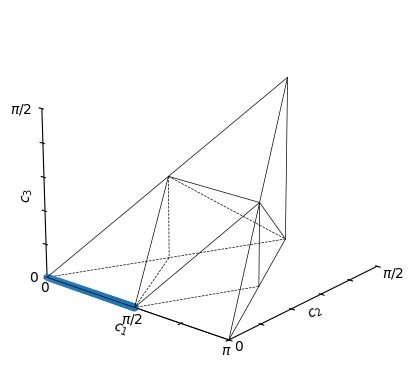

In [ ]:
from gulps.viz.invariant_viz import scatter_plot

scatter_plot(inv_list)

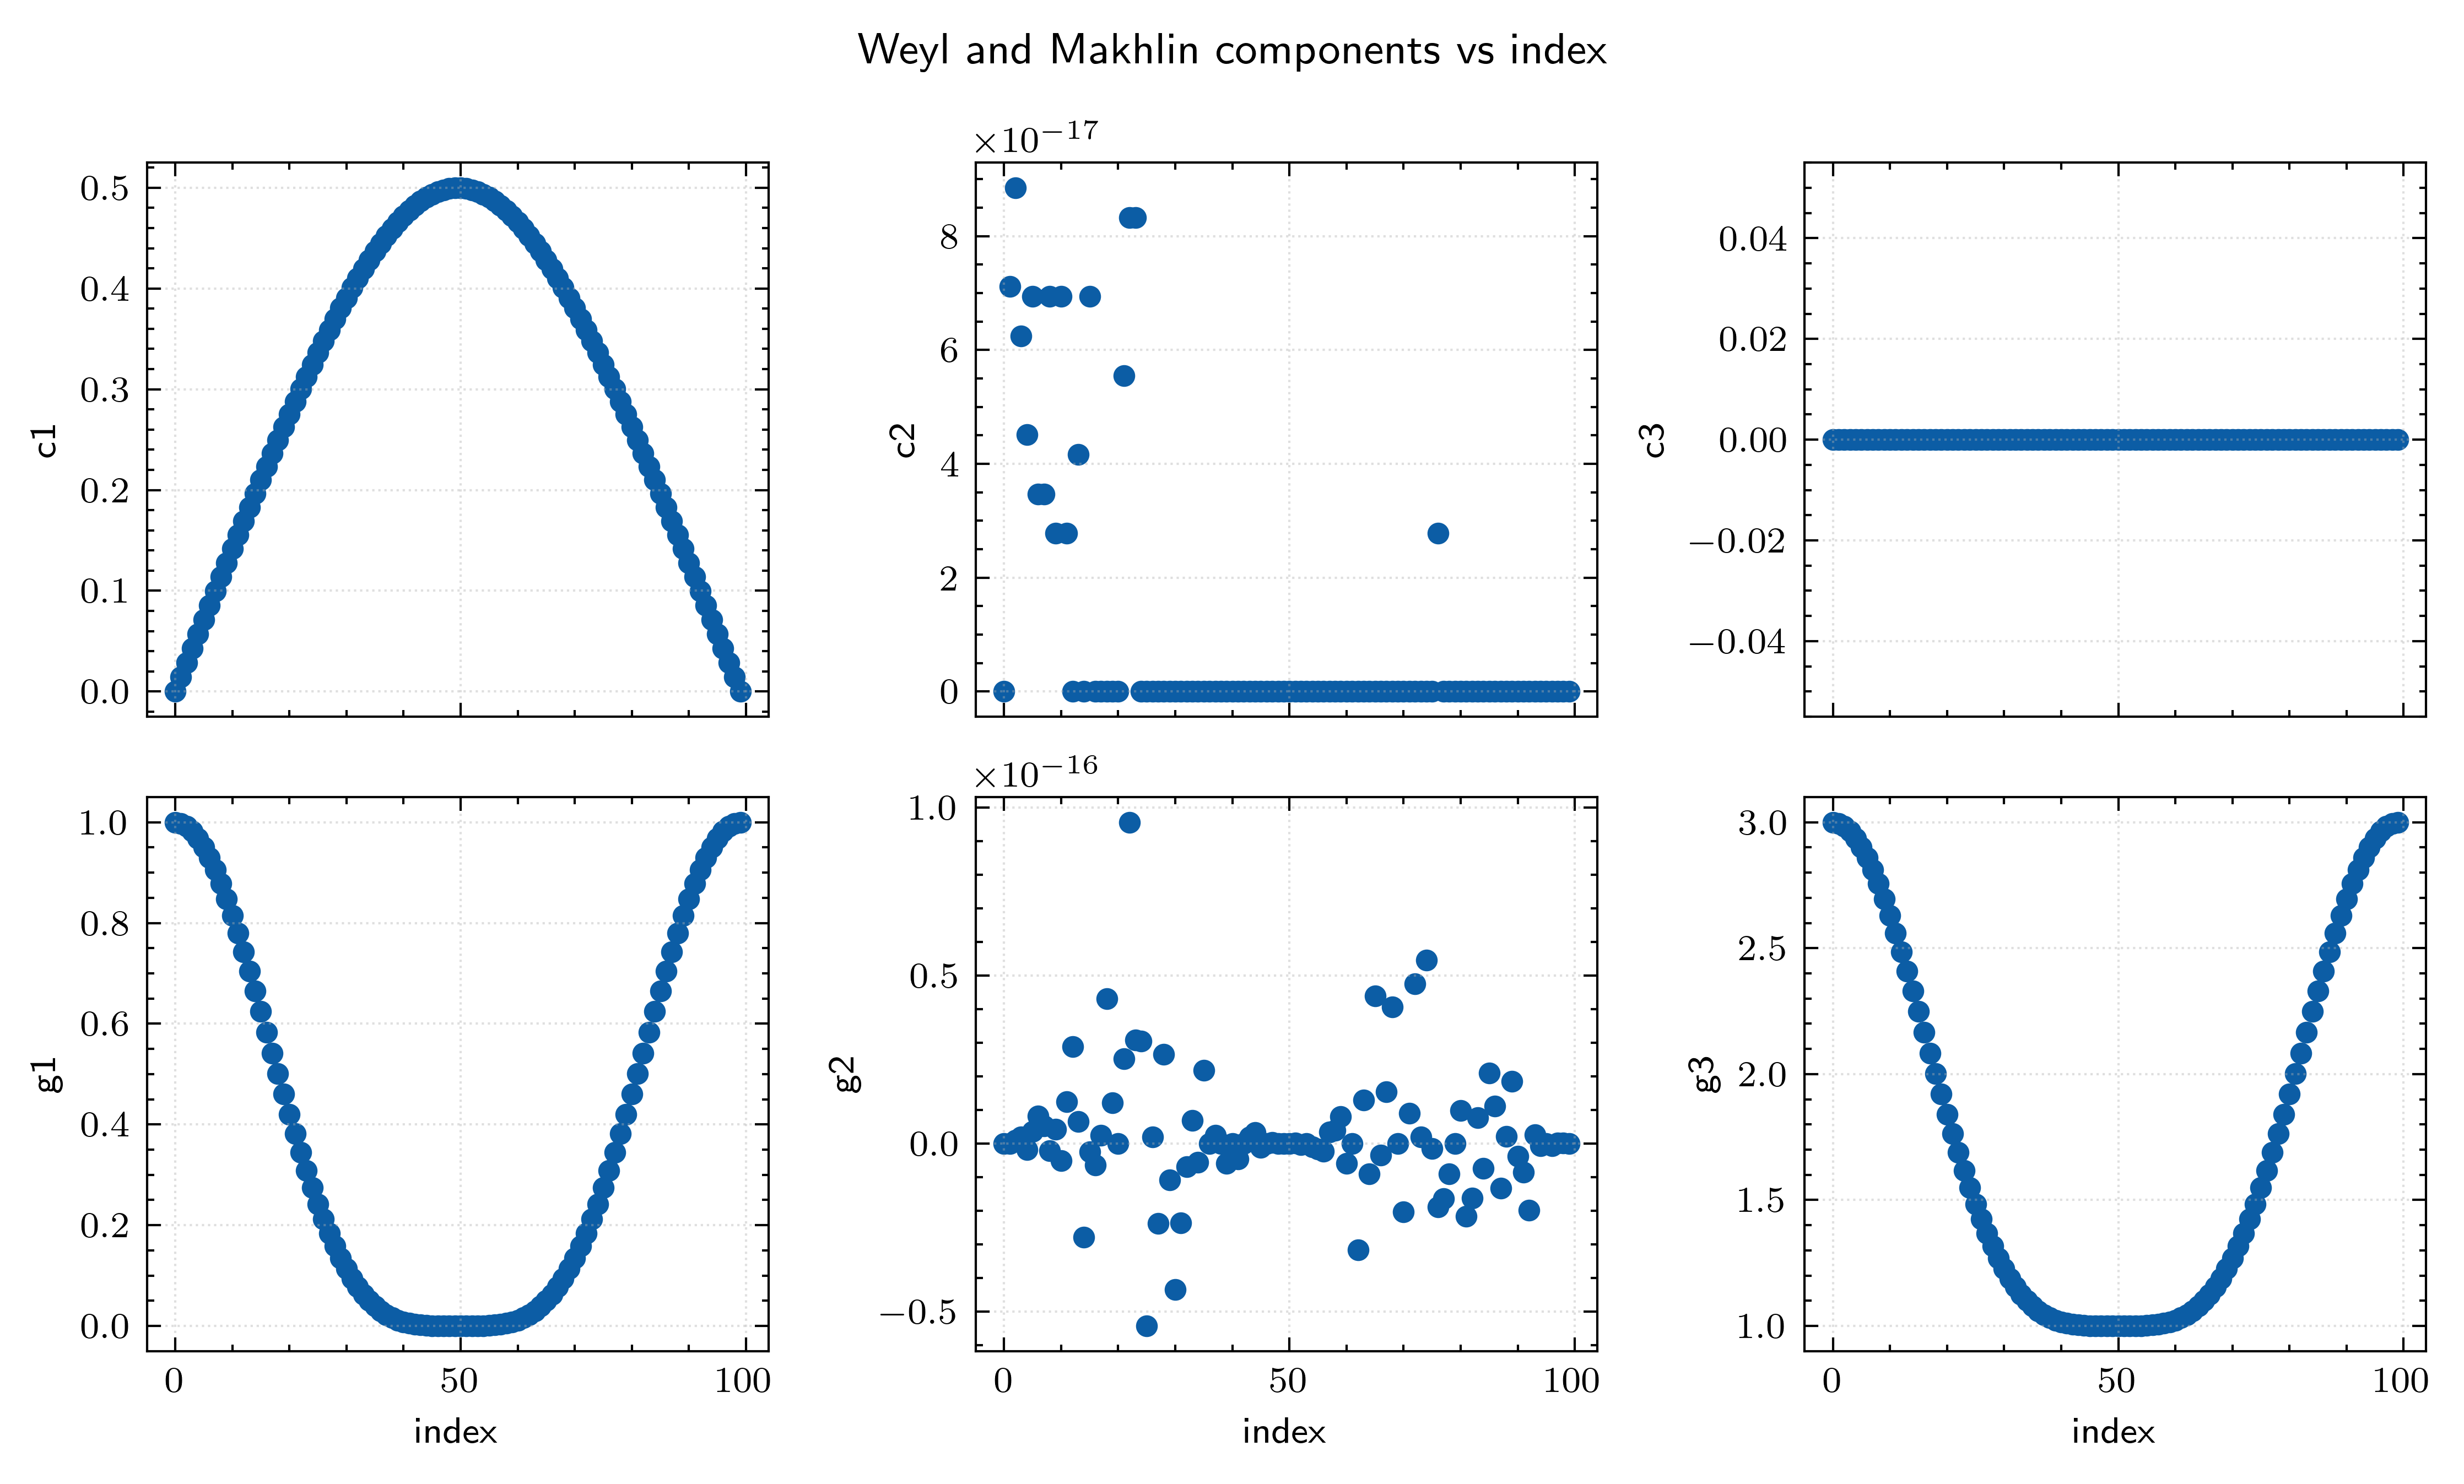

In [13]:
# Scatter of Weyl (c1,c2,c3) and Makhlin (g1,g2,g3) vs index
import numpy as np
import matplotlib.pyplot as plt

if "inv_list" not in globals() or len(inv_list) == 0:
    print("inv_list is empty or undefined; run the generation cell first.")
else:
    weyls = np.array([inv.weyl for inv in inv_list])
    makhlins = np.array([inv.makhlin for inv in inv_list])
    x = np.arange(len(inv_list))

    with plt.style.context(["ieee", "science", "use_mathtext"]):
        fig, axs = plt.subplots(2, 3, figsize=(7.5, 4.5), sharex=True)

        # Top row: Weyl components c1, c2, c3
        weyl_labels = ["c1", "c2", "c3"]
        for j in range(3):
            ax = axs[0, j]
            ax.scatter(x, weyls[:, j], s=14)
            ax.set_ylabel(weyl_labels[j])
            ax.grid(True, linestyle=":", alpha=0.4)

        # Bottom row: Makhlin components g1, g2, g3
        makhlin_labels = ["g1", "g2", "g3"]
        for j in range(3):
            ax = axs[1, j]
            ax.scatter(x, makhlins[:, j], s=14)
            ax.set_ylabel(makhlin_labels[j])
            ax.set_xlabel("index")
            ax.grid(True, linestyle=":", alpha=0.4)

        fig.suptitle("Weyl and Makhlin components vs index")
        fig.tight_layout()
plt.show()